# 🔍 Results 

In this notebook, we present the results obtained in the estimation of the ground state energy for two molecular Hamiltonians: hydrogen $H_{2}$ and water $H_{2}O$.

The reported results were achieved by tuning five different hyperparameters for each optimisation model using Optuna. To improve the statistical reliability, each hyperparameter configuration was executed twice.

Now, if you're wondering whether this level of hyperparameter tuning is sufficient—honestly, **it’s not**. In a more ideal setting, a broader exploration would have been carried out. However, due to limited computational resources, especially for larger molecules and complex ansatze with many gates/parameters, a more extensive sweep wasn’t feasible.

Ground state energy estimation was carried out using various classical optimisation techniques, including SPSA, Bayesian Optimisation (BO) and other more novel ones such as Reinforcement Learning (RL).

All models were developed using a shared base configuration:

   - Jordan–Wigner mapping for qubit transformation

   - Hartree–Fock as the initial state

   - UCCSD ansatz as the quantum circuit

This consistent baseline allows a fair comparison between optimisers. While this base configuration was not optimised in this work, the code is modular and prepared for future modifications in both the mapping and ansatz design.

In [1]:
import matplotlib.pylab as plt
import numpy as np
import json
import sys
sys.path.insert(1, '../results/')

## $H_2$ Ground State Energy
Below, we present the results obtained for estimating the ground state energy of the hydrogen molecule ($\mathrm{H}_2$).
These results showcase the performance of different optimisation strategies applied to a relatively simple quantum system, serving as a reference for evaluating accuracy, convergence, and robustness of each method.

In [2]:
def read_results(path, name):
    with open(f"{path}{name}.json", 'r') as f:
        results = json.load(f)  
    return results  

path_folder = "../results/"
results_spsa = read_results(path_folder, "best_trial_h2_spsa")
#results_lbfgsb = read_results(path_folder, "best_trial_h2_lbfgsb")
results_bo_observables = read_results(path_folder, "best_trial_h2_bo_observables")
results_bo_eigenvalue = read_results(path_folder, "best_trial_h2_bo_eigenvalue")
results_ppo = read_results(path_folder, "best_trial_h2_rl_ppo")
results_td3 = read_results(path_folder, "best_trial_h2_rl_td3")

ground_state_energy = results_ppo["ground_state_energy"]
ground_state_energy

-1.137306035753399

Mean Eigenvalue
SPSA: -0.8903416112587978
BO Eigenvalue: -0.9342472325671742
BO Observables: -0.9342472068352848
RL PPO: -0.9334678549921627
RL TD3: -0.9338170618912569


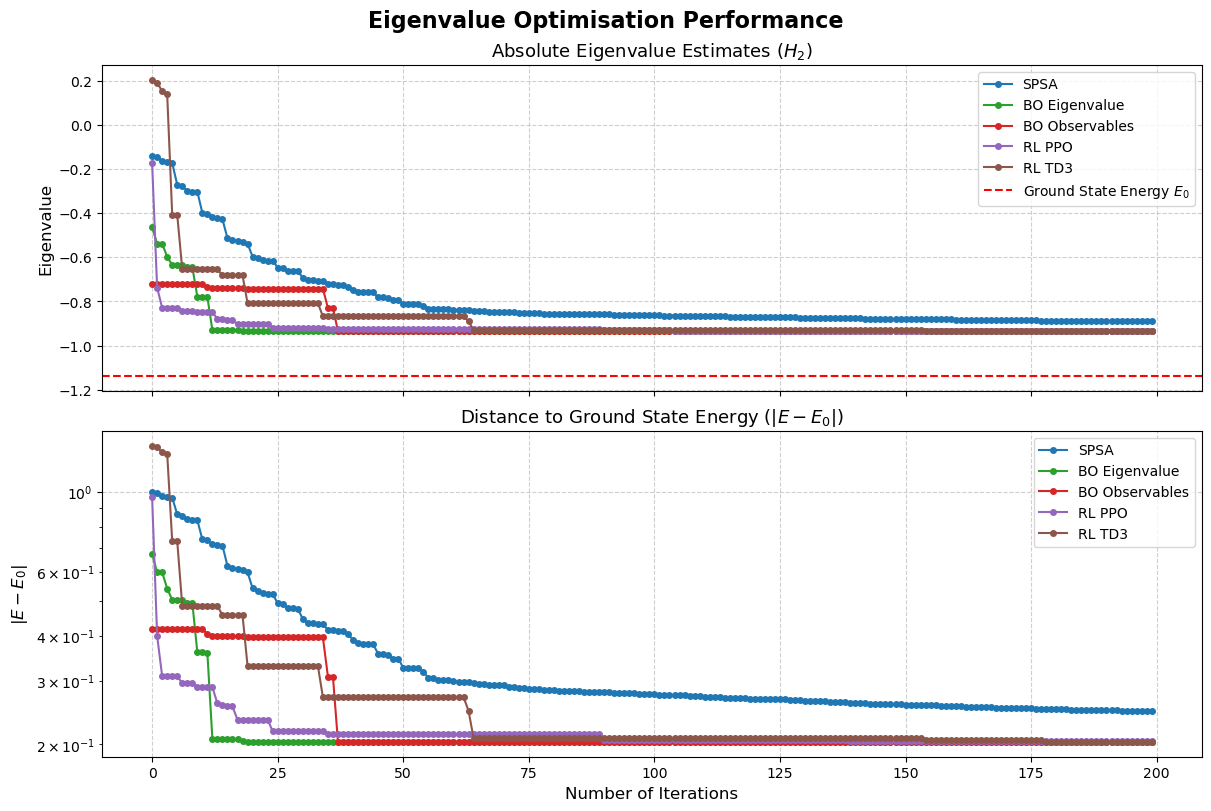

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(2, 1, figsize=(12, 8), facecolor='white', constrained_layout=True, sharex=True)

plt.suptitle('Eigenvalue Optimisation Performance', fontsize=16, fontweight='bold')

n_samples = np.arange(len(results_ppo["best_metrics"]['history_best_eigenvalue_runs'][0]))

# Colors and labels for consistent plotting
methods = [
    ('SPSA', results_spsa, 'C0'),
    #('L-BFGS-B', results_lbfgsb, 'C1'),
    ('BO Eigenvalue', results_bo_eigenvalue, 'C2'),
    ('BO Observables', results_bo_observables, 'C3'),
    ('RL PPO', results_ppo, 'C4'),
    ('RL TD3', results_td3, 'C5'),
    ]

# === Plot absolute eigenvalues
print('Mean Eigenvalue')
ax[0].set_title(r'Absolute Eigenvalue Estimates ($H_2$)', fontsize=13)
for label, result, color in methods:
    mean_vals = np.mean(np.array(result['best_metrics']['history_best_eigenvalue_runs']), axis=0)
    ax[0].plot(n_samples, mean_vals, '-o', label=label, linewidth=1.5, markersize=4, color=color)
    print(f"{label}: {mean_vals[-1]}")


ax[0].axhline(ground_state_energy, linestyle='--', color='r', linewidth=1.5, label=r'Ground State Energy $E_0$')
ax[0].set_ylabel('Eigenvalue', fontsize=12)
ax[0].legend(loc='upper right', fontsize=10)
ax[0].grid(True, linestyle='--', alpha=0.6)

# === Plot difference from ground state (log scale)
ax[1].set_title(r'Distance to Ground State Energy ($|E - E_0|$)', fontsize=13)
for label, result, color in methods:
    diff = np.mean(np.array(result['best_metrics']['history_best_eigenvalue_runs']), axis=0) - ground_state_energy
    ax[1].plot(n_samples, np.abs(diff), '-o', label=label, linewidth=1.5, markersize=4, color=color)
    

ax[1].set_yscale('log')
ax[1].set_ylabel(r'$|E - E_0|$', fontsize=12)
ax[1].set_xlabel('Number of Iterations', fontsize=12)
ax[1].legend(loc='upper right', fontsize=10)
ax[1].grid(True, linestyle='--', alpha=0.6)


plt.savefig('../figures/results_h2_eigenvalue.png', bbox_inches='tight', dpi=300)
plt.show()


### Results Analysis: 

The figure above shows that most models converge to similar eigenvalue estimates, albeit at different rates. One notable exception is the model based on SPSA, which consistently reaches a higher (less optimal) eigenvalue compared to the others.

Overall, none of the models manage to reach the true ground state energy of the $H_2$ molecule. This limitation is primarily due to the chosen ansatz: its fixed architecture restricts the expressibility required to accurately represent the true ground state.

Despite this, the classical optimisers themselves appear to perform as expected within the constraints of the ansatz, effectively navigating the parameter landscape toward the best solution allowed by the circuit.

## $H_2O$ Ground State Energy
Below, we present the results obtained for estimating the ground state energy of the water molecule ($\mathrm{H}_2\mathrm{O}$).
These results showcase the performance of different optimisation strategies applied to a relatively complex quantum system, serving as a reference for evaluating accuracy, convergence, and robustness of each method.


In [4]:
path_folder = "../results/"
results_spsa = read_results(path_folder, "best_trial_h2o_spsa")
results_bo_eigenvalue = read_results(path_folder, "best_trial_h2o_bo_eigenvalue")
results_ppo = read_results(path_folder, "best_trial_h2o_rl_ppo")
results_td3 = read_results(path_folder, "best_trial_h2o_rl_td3")
ground_state_energy = results_ppo["ground_state_energy"]


Mean Eigenvalue
SPSA: 33.54858450452882
BO Eigenvalue: 17.439720618272403
RL PPO: 3.659763199595412
RL TD3: 14.667605968292463


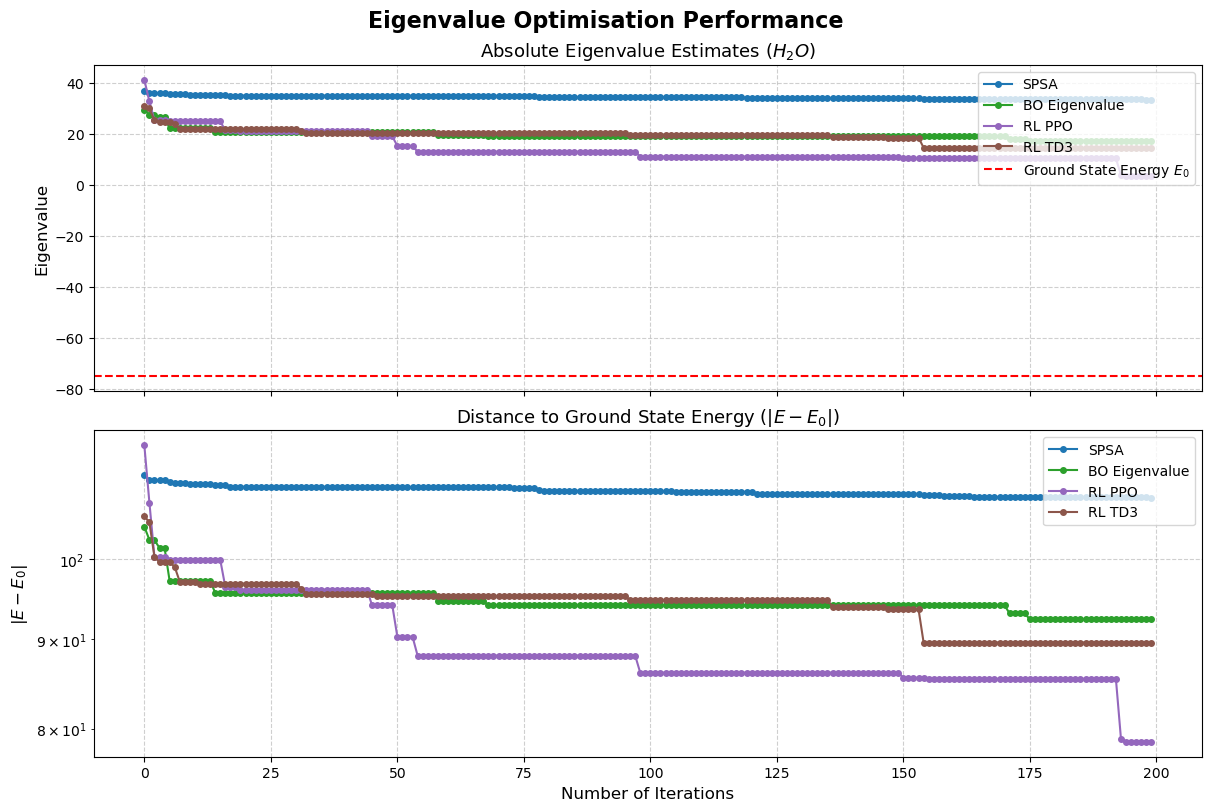

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(2, 1, figsize=(12, 8), facecolor='white', constrained_layout=True, sharex=True)

plt.suptitle('Eigenvalue Optimisation Performance', fontsize=16, fontweight='bold')

n_samples = np.arange(len(results_ppo["best_metrics"]['history_best_eigenvalue_runs'][0]))

# Colors and labels for consistent plotting
methods = [
    ('SPSA', results_spsa, 'C0'),
    #('L-BFGS-B', results_lbfgsb, 'C1'),
    ('BO Eigenvalue', results_bo_eigenvalue, 'C2'),
    ('RL PPO', results_ppo, 'C4'),
    ('RL TD3', results_td3, 'C5'),
    ]

# === Plot absolute eigenvalues
print('Mean Eigenvalue')

ax[0].set_title(r'Absolute Eigenvalue Estimates ($H_2O$)', fontsize=13)
for label, result, color in methods:
    mean_vals = np.mean(np.array(result['best_metrics']['history_best_eigenvalue_runs']), axis=0)
    print(f"{label}: {mean_vals[-1]}")
    ax[0].plot(n_samples, mean_vals, '-o', label=label, linewidth=1.5, markersize=4, color=color)

ax[0].axhline(ground_state_energy, linestyle='--', color='r', linewidth=1.5, label=r'Ground State Energy $E_0$')
ax[0].set_ylabel('Eigenvalue', fontsize=12)
ax[0].legend(loc='upper right', fontsize=10)
ax[0].grid(True, linestyle='--', alpha=0.6)

# === Plot difference from ground state (log scale)
ax[1].set_title(r'Distance to Ground State Energy ($|E - E_0|$)', fontsize=13)
for label, result, color in methods:
    diff = np.mean(np.array(result['best_metrics']['history_best_eigenvalue_runs']), axis=0) - ground_state_energy
    ax[1].plot(n_samples, np.abs(diff), '-o', label=label, linewidth=1.5, markersize=4, color=color)

ax[1].set_yscale('log')
ax[1].set_ylabel(r'$|E - E_0|$', fontsize=12)
ax[1].set_xlabel('Number of Iterations', fontsize=12)
ax[1].legend(loc='upper right', fontsize=10)
ax[1].grid(True, linestyle='--', alpha=0.6)


plt.savefig('../figures/results_h2o_eigenvalue.png', bbox_inches='tight', dpi=300)
plt.show()


### Results Analysis: 

The figure above illustrates that, unlike in the previous example, the models converge to noticeably different eigenvalue estimates. Among them, the PPO-based model achieves the best result, demonstrating the most effective convergence.

However, as with the $H_2$ case, none of the models reach the true ground state energy. This discrepancy is expected, as we are now dealing with the more complex $H_2O$ molecule, which features a larger Hamiltonian and requires a more intricate ansatz. The increased number of parameters and the more rugged optimisation landscape make the task significantly more challenging.

Despite not achieving the exact ground state, the PPO-based model stands out as particularly promising for high-dimensional problems. Its ability to handle a complex parameter space suggests its potential for larger molecules and more demanding quantum simulations.


## 🔧 Future Improvement: Adaptive Ansatz 

To further enhance the accuracy and scalability of VQE for larger systems like $H_2O$, is the use of Adaptive Ansatz (e.g., ADAPT-VQE): Dynamically constructs the ansatz by selecting the most relevant operators based on the system’s gradient information. This reduces circuit depth while preserving expressiveness.